# 03 - Diseno D-optimo para regiones irregulares

Los disenos clasicos (factorial, Box-Behnken, CCD) asumen una region **regular** (un cubo o
una esfera) y un numero de corridas fijo por plantilla. En la practica muchas veces:

- la region experimental es **irregular** (hay combinaciones prohibidas),
- tenemos un **presupuesto fijo** de corridas que no encaja con ninguna plantilla,
- queremos un **modelo a medida** (ciertas interacciones y cuadraticos).

El **diseno optimo** resuelve esto: dado un conjunto de puntos candidatos y un modelo,
selecciona el subconjunto que maximiza un criterio de informacion. El mas comun es la
**D-optimalidad** (maximizar `det(X'X)`), que aqui se resuelve con el algoritmo
**KL-exchange**. Este es el aporte central del paquete frente a `pyDOE`/plantillas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import doekit as ed

rng = np.random.default_rng(11)
plt.rcParams["figure.figsize"] = (6, 5)

## 1. Una region candidata irregular

Construimos una grilla de candidatos en `[-1, 1]^2` y **recortamos** una esquina prohibida
(por ejemplo, temperatura alta con presion alta seria inseguro). Ninguna plantilla clasica
cubre esta forma; el diseno optimo si.

candidatos validos: 200


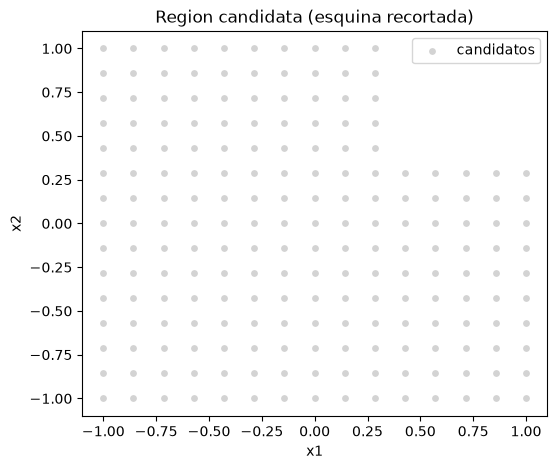

In [2]:
grid = ed.full_factorial({"x1": np.linspace(-1, 1, 15), "x2": np.linspace(-1, 1, 15)})
cand_df = grid.matrix
mask = ~((cand_df["x1"] > 0.4) & (cand_df["x2"] > 0.4))   # esquina prohibida
cand_df = cand_df[mask].reset_index(drop=True)

candidates = ed.Design(matrix=cand_df,
                       model=ed.Model.parse("0 ~ x1 + x2 + x1:x2 + x1^2 + x2^2"))
print("candidatos validos:", candidates.n_runs)

fig, ax = plt.subplots()
ax.scatter(cand_df["x1"], cand_df["x2"], s=15, c="lightgray", label="candidatos")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_title("Region candidata (esquina recortada)")
ax.legend(); plt.show()

## 2. Seleccionar un diseno D-optimo

Pedimos **12 corridas** que maximicen la D-optimalidad para un modelo cuadratico con
interaccion. Usamos multi-arranque (`n_starts`) para reducir el riesgo de optimo local.

criterios del diseno: {'D': 0.40632, 'A': 0.259266, 'T': 0.635291, 'G': 8.30838, 'E': 0.089216, 'I': 2.638942}


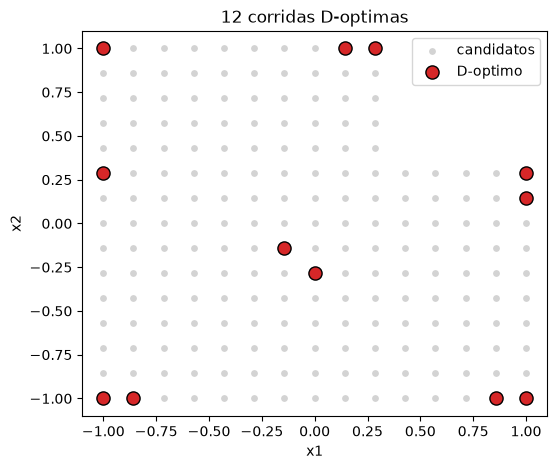

In [3]:
opt = ed.optimal_design(candidates, n_runs=12, criterion="D", n_starts=20, seed=1)
print("criterios del diseno:", opt.metadata["criteria"])

sel = opt.matrix
fig, ax = plt.subplots()
ax.scatter(cand_df["x1"], cand_df["x2"], s=15, c="lightgray", label="candidatos")
ax.scatter(sel["x1"], sel["x2"], s=90, c="tab:red", edgecolor="black", label="D-optimo")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_title("12 corridas D-optimas")
ax.legend(); plt.show()

El diseno empuja los puntos hacia los **bordes y esquinas accesibles** de la region: alli
es donde mas informacion se gana para estimar los coeficientes. Note como respeta la esquina
prohibida.

## 3. Cuanto mejor que elegir al azar

Comparamos la D-optimalidad del diseno KL contra la distribucion de D que se obtiene
eligiendo 12 puntos **al azar** del mismo conjunto candidato.

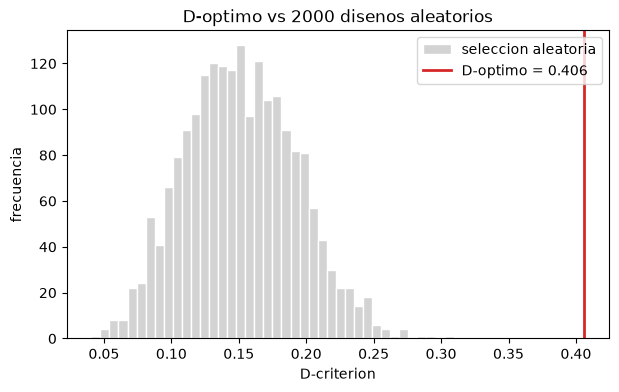

D aleatorio: media 0.151, max 0.309
D optimo:    0.406


In [4]:
X_full = candidates.model.matrix(candidates.matrix)
N = candidates.n_runs
rand_D = np.array([ed.d_criterion(X_full[rng.choice(N, 12, replace=False)]) for _ in range(2000)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rand_D, bins=40, color="lightgray", edgecolor="white", label="seleccion aleatoria")
ax.axvline(opt.metadata["criteria"]["D"], color="tab:red", lw=2,
           label=f"D-optimo = {opt.metadata['criteria']['D']:.3f}")
ax.set_xlabel("D-criterion"); ax.set_ylabel("frecuencia")
ax.set_title("D-optimo vs 2000 disenos aleatorios"); ax.legend(); plt.show()

print(f"D aleatorio: media {rand_D.mean():.3f}, max {rand_D.max():.3f}")
print(f"D optimo:    {opt.metadata['criteria']['D']:.3f}")

## 4. El multi-arranque ayuda a converger

El KL-exchange converge a un optimo **local** desde el arranque aleatorio. Con mas arranques
tomamos el mejor y nos acercamos al optimo global. Lo cuantificamos.

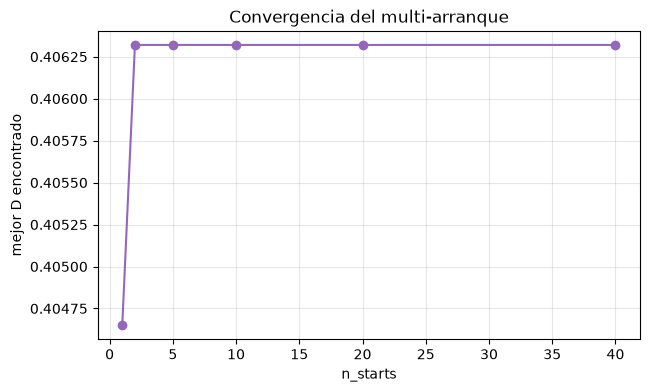

In [5]:
def best_D(n_starts):
    d = ed.optimal_design(candidates, n_runs=12, criterion="D",
                          n_starts=n_starts, seed=1)
    return d.metadata["criteria"]["D"]

starts = [1, 2, 5, 10, 20, 40]
curve = [best_D(s) for s in starts]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(starts, curve, "o-", color="tab:purple")
ax.set_xlabel("n_starts"); ax.set_ylabel("mejor D encontrado")
ax.set_title("Convergencia del multi-arranque"); ax.grid(alpha=0.3); plt.show()

## 5. Distintos criterios, distintos disenos

D no es el unico objetivo. **A-optimalidad** minimiza la varianza promedio de los
coeficientes; **I-optimalidad** minimiza la varianza de **prediccion** sobre la region (util
si el objetivo es predecir, no estimar parametros). Para criterios distintos de D usamos el
intercambio de **Fedorov**. Comparamos los tres disenos.

In [6]:
rows = []
for crit in ["D", "A", "I"]:
    d = ed.optimal_design(candidates, n_runs=12, criterion=crit, n_starts=8, seed=2)
    rows.append({"criterio_objetivo": crit, **{k: round(v, 4)
                 for k, v in d.metadata["criteria"].items()}})
pd.DataFrame(rows).set_index("criterio_objetivo")

,D,A,T,G,E,I
criterio_objetivo,,,,,,
D,0.4063,0.2593,0.6353,8.3084,0.0892,2.6389
A,0.3909,0.2970,0.5498,6.5665,0.1299,2.9621
I,0.3837,0.2867,0.5511,6.5710,0.1254,2.9849


Cada diseno es el mejor en **su propio** criterio (diagonal), evidenciando el compromiso
entre objetivos. La eleccion depende de la meta: estimar parametros (D/A) o predecir (I).

**Conclusion.** Cuando la region es irregular, el presupuesto es fijo o el modelo es a
medida, el diseno optimo es la herramienta adecuada, y `doekit` lo ofrece con
eleccion de criterio, algoritmo y multi-arranque.

## Evaluación del diseño óptimo (nuevo en doekit)

El boletín cuantifica cuánto gana el diseño óptimo frente a uno aleatorio del
mismo tamaño.

In [7]:
import doekit as ed
import numpy as np, pandas as pd

cand = ed.random_design([ed.ContinuousFactor("x1",-1,1), ed.ContinuousFactor("x2",-1,1)],
                        n=200, seed=0)
cand.model = ed.Model.parse("0 ~ x1 + x2 + x1:x2")
opt = ed.optimal_design(cand, n_runs=10, criterion="D", n_starts=5, seed=1)
rng = np.random.default_rng(0)
rnd = ed.Design(matrix=cand.matrix.iloc[rng.choice(200,10,replace=False)].reset_index(drop=True),
                model=cand.model)
for nombre,d in [("D-optimo",opt),("Aleatorio",rnd)]:
    e = ed.efficiencies(d, seed=0)
    print("%-10s  D-eff=%.1f%%  A-eff=%.1f%%" % (nombre, e["D_efficiency"], e["A_efficiency"]))


D-optimo    D-eff=77.8%  A-eff=75.4%
Aleatorio   D-eff=29.1%  A-eff=17.5%


## Puente: asesor con `Constraints` (región irregular)

En vez de solo filtrar candidatos a mano, el advisor acepta `Constraints(irregular=True)`
(reemplaza el booleano deprecado `constrained=True`).


In [8]:
r = ed.recommend_design(
    "optimization", factors=2, budget=12,
    constraints=ed.Constraints(irregular=True), seed=0,
)
print("método:", r.method)
print(r.rationale)
print("caveats:", r.caveats[:3])
path = ed.experiment(design=opt).export_csv("reports/03_optimo/runs.csv")
print("CSV escrito:", path)


método: D-optimal
To model the response surface and locate the optimum with 2 factors with a budget of 12 runs and a 'quadratic' model, the best compromise under your priorities is D-optimal (9 runs, D-efficiency 46.2%, G-efficiency 84.6%).
caveats: ["Recommendation is conditional on model_order='quadratic' (and effect_size=1.0 for power).", '"Best" is a multi-objective trade-off (runs vs precision vs prediction): adjust \'priorities\' for your case.', 'After the first experimental wave, use propose_next_runs / augment_design to choose the next batch (sequential DoE) instead of restarting from scratch.']
CSV escrito: reports\03_optimo\runs.csv


## Reporte del experimento (guía semántica)

El cierre de todo DoE es el **reporte**: qué se hizo, qué tan bueno fue el diseño, qué observar y qué concluir. Generamos el reporte en carpeta (`index.html` + CSS/imágenes/datos; o `self_contained=True` para un único HTML) y mostramos su **guía semántica inline** para validar que coincide con lo que el análisis de arriba mostró.

In [9]:
rep = ed.report(opt, output_dir="reports/03_optimo", title="Diseno optimo",
                lang="es")
guide = ed.report_summary(opt)

print("METODOLOGIA\n ", guide["methodology"], "\n")
print("RESUMEN EJECUTIVO")
for b in guide["executive_summary"]:
    print("  -", b)
print("\nRECOMENDACIONES (que accionar / que observar)")
for r in guide["recommendations"]:
    print("  ->", r)
an = guide["anomalies"]
if an is not None and len(an):
    print("\nVALORES ANOMALOS (corridas a revisar):")
    print(an.to_string(index=False))
print("\nReporte (carpeta index.html + assets) en:", rep)


METODOLOGIA
  Optimal design: subset that maximizes information under the chosen criterion, useful in constrained regions. Criterion D via kl. 

RESUMEN EJECUTIVO
  - Design quality: D-efficiency 78% (acceptable), G-efficiency 61%.

RECOMENDACIONES (que accionar / que observar)

Reporte (carpeta index.html + assets) en: reports\03_optimo\index.html


## ¿Fue el diseño apropiado? (asesor de doekit)

Cierre: el asesor infiere el escenario de lo ejecutado y recomienda el método más apropiado, comparándolo con lo que hicimos — una recomendación coherente con el experimento. El 'mejor' es un trade-off (corridas vs precisión vs predicción); por eso se muestran las alternativas.

In [10]:
rec = guide["recommendation"]
if rec:
    print("DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO")
    print(" ", rec["note"])
    print()
    print(rec["table"].to_string(index=False))
else:
    print("(sin recomendacion: el diseno no tiene modelo asociado)")


DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO
  For this case (screening, 2 factors, model 'interactions', budget 10), the more efficient design would be Plackett-Burman; you ran D-optimal. This is informative, not an error: review the alternatives table and choose by your priorities.

              method  runs  D_eff  G_eff  SPV_mean  in_budget  supports_model
     Plackett-Burman     4  100.0  100.0      1.76       True            True
Definitive Screening     5    NaN    NaN       NaN       True           False
      Full factorial     4  100.0  100.0      1.78       True            True
